# Post-Processing

This notebook assumes that it lives in the same folder as the folders `Libraries`, `Climate`, the data from simulations `wallx_loc=yyyy.h5` and the notebook `weathertools.ipynb` and `weathertools.py`




In [1]:
import time
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np
import math
import scipy.constants as sc
from scipy.constants import convert_temperature
from scipy.optimize import fsolve
import h5py

import sympy as sym
import sys

    
font = {'family' : 'serif',
        #'color'  : 'black',
        'weight' : 'normal',
        'size'   : 16,
        }
fontlabel = {'family' : 'serif',
        #'color'  : 'black',
        'weight' : 'normal',
        'size'   : 16,
        }

from matplotlib.ticker import FormatStrFormatter
plt.rc('font', **font)
from Libraries import numericsv2 as num
import weathertools as wtools
oneminute = 60.
onehour = 3600.0
oneday = 24*onehour
oneweek = 7*oneday

In [5]:
import pandas as pd
weather = {}
weatherfct = {}
for loc in ['Lake Placid, NY', 'Soldier Hollow, UT']:
    
    weather[loc] = pd.read_excel("Climate/April-October-2020.xlsx",
                            sheet_name=loc,header=0,
                            converters= {'Date time': pd.to_datetime},)
    weather[loc] = weather[loc].set_index('Date time')
    
    weatherfct[loc] = wtools.WeatherData(weather[loc])
weather[loc]['Name'].head(1)


Date time
2020-04-01    Soldier Hollow Dr, Midway, UT 84049, United St...
Name: Name, dtype: object


## Definition of variables availables in dump files

Dump files are named `wallxx_loc=yyyy.h5` where `xx` is the wall number (see below) and `yyyy` the location. They store the following variables:
* `'t'` time in second at which data was collected. 1D array of dimension $N_{samples}$
* `'H_t'`: height of enclosure for all collected instances. 1D array of dimension $N_{samples}$
* `'xs'`: Location of computational nodes used to discretize the roof. 1D array of dimension $N_{nodes}$
* `'enthalpy'`: total enthalpy of the roof for all collected instances. 1D array of dimension $N_{samples}$
* `'Tprofiles'`: profiles of temperatures within the roof for all collected instances. 2D array of dimensions $(N_{samples},N_{nodes})$ where $N_{nodes}$ is the number of computational nodes used to discretize the roof.
* `'qppx0and1'`: wall heat fluxes for all collected instances. 2D array of dimensions $(N_{samples},2)$ where the second index is for inner $i=0$ or outer $i=1$ roof surfaces.
* `'k'`: Distribution of thermal conductivity of the computational nodes. 1D array of dimension $N_{nodes}$
* `'rhoCp'`: Distribution of product density by specific heat of the computational nodes. 1D array of dimension $N_{nodes}$

## Definition of variables availables in object `weatherfct`
All functions provide information at any time $t$ within the period over which weather data is available.
* `weatherfct.U_atmospheric(t)` : wind speed
* `weatherfct.T_atmospheric(t)` : Ambiant temperature
* `weatherfct.sun_irradiation(t)` : Solar irradiation
* `weatherfct.cloud_cover(t)` : cloud cover
* `weatherfct.dew_point(t)` : dew point temperature
* `weatherfct.relative_humidity(t)` : relative humidity
* `weatherfct.rain_rate(t)` : rain rate

and the radiation to the sky, outside convection, and heat transfer by train fluxes are given by the functions:
* `weatherfct.qpp_skyradiation(t,wall.T[-1])` where `wall.T[-1]` is the roof's outer surface temperature.
* `weatherfct.qpp_outsideconvection(t,wall.T[-1],Length)`
* `weatherfct.qpp_rain(t,wall.T[-1])`

## Definition of thermodynamic properties of wall materials

In [6]:
rhodict = {}; kdict = {}; Cpdict = {}; alphadict = {}
# Polystyrene expanded extruded
rhodict['xps'] = 55 #kg/m^3
kdict['xps'] = 0.027 #W/m.K
Cpdict['xps'] = 1210 #J/kg.K
alphadict['xps'] = kdict['xps']/(rhodict['xps']*Cpdict['xps'])
print("Thermal diffusivity of XPS: %.2e m^2/s" %alphadict['xps'])

# Soft solid wood
rhodict['swood'] = 510 #kg/m^3
kdict['swood'] = 0.12 #W/m.K
Cpdict['swood'] = 1380 #J/kg.K
alphadict['swood'] = kdict['swood']/(rhodict['swood']*Cpdict['swood'])
print("Thermal diffusivity of soft wood: %.2e m^2/s" %alphadict['swood'])

# Compressed wood fiber
# https://www.betonwood.com/eng/wood-fiber-therm.html
rhodict['woodfiber'] = 160 #kg/m^3
kdict['woodfiber'] = 0.038 #W/m.K
Cpdict['woodfiber'] = 2100 #J/kg.K
alphadict['woodfiber'] = kdict['woodfiber']/(rhodict['woodfiber']*Cpdict['woodfiber'])
print("Thermal diffusivity of compressed wood fiber: %.2e m^2/s" %alphadict['woodfiber'])

# https://www.betonwood.com/eng/wood-fiber-flex60.html
rhodict['woodfiber60'] = 60 #kg/m^3
kdict['woodfiber60'] = 0.036 #W/m.K
Cpdict['woodfiber60'] = 2100 #J/kg.K
alphadict['woodfiber60'] = kdict['woodfiber60']/(rhodict['woodfiber60']*Cpdict['woodfiber60'])
print("Thermal diffusivity of compressed wood fiber flex 60: %.2e m^2/s" %alphadict['woodfiber60'])
# Concrete
rhodict['concrete'] = 1860 #kg/m^3
kdict['concrete'] = 0.72 #W/m.K
Cpdict['concrete'] = 780 #J/kg.K
alphadict['concrete'] = kdict['concrete']/(rhodict['concrete']*Cpdict['concrete'])
print("Thermal diffusivity of concrete: %.2e m^2/s" %alphadict['concrete'])

#Hempcrete
rhodict['hempcrete'] = 460 #kg/m^3
kdict['hempcrete'] = 0.08 #W/m.K
Cpdict['hempcrete'] = 1400 #J/kg.K
alphadict['hempcrete'] = kdict['hempcrete']/(rhodict['hempcrete']*Cpdict['hempcrete'])
print("Thermal diffusivity of hempcrete: %.2e m^2/s" %alphadict['hempcrete'])

Thermal diffusivity of XPS: 4.06e-07 m^2/s
Thermal diffusivity of soft wood: 1.71e-07 m^2/s
Thermal diffusivity of compressed wood fiber: 1.13e-07 m^2/s
Thermal diffusivity of compressed wood fiber flex 60: 2.86e-07 m^2/s
Thermal diffusivity of concrete: 4.96e-07 m^2/s
Thermal diffusivity of hempcrete: 1.24e-07 m^2/s


In [8]:
weatherfct['Lake Placid, NY'].t[-1]/oneday

213.0

## Definition of wall compositions
Feel free to add your own composition by adding a case or two. All you need is to specify your materials and the thickness of each materials.

In [10]:
def build_layers(Nlayers,thicknesses):
    xlayers = np.zeros((Nlayers,2))
    xlayers[0,1] = thicknesses[0]
    if Nlayers > 1:
        for n in range(1,Nlayers):
            xlayers[n,0] = xlayers[n-1,1]
            xlayers[n,1] = xlayers[n,0] + thicknesses[n]

    return xlayers
def wall_definition(wallnumber):
    match wallnumber:
        case 0:
            materials = ['swood', 'concrete']
            thicknesses = np.array([0.005,0.05])
            Nnodes = np.array([5,21])
            Nlayers = len(materials)
            xlayers = build_layers(Nlayers,thicknesses)
        #========================
        case 1:
            materials = ['swood', 'xps', 'concrete']
            thicknesses = np.array([0.005,0.025,0.05])
            Nnodes = np.array([5,15,21])
            Nlayers = len(materials)
            xlayers = build_layers(Nlayers,thicknesses)
        #========================
        case 2:
            materials = ['swood', 'xps', 'hempcrete']
            thicknesses = np.array([0.005,0.025,0.05])
            Nnodes = np.array([5,15,21])
            Nlayers = len(materials)
            xlayers = build_layers(Nlayers,thicknesses)
        #========================
        case 3:
            materials = ['swood', 'xps', 'concrete']
            thicknesses = np.array([0.005,0.025,0.1])
            Nnodes = np.array([5,15,41])
            Nlayers = len(materials)
            xlayers = build_layers(Nlayers,thicknesses)
        #========================
        case 4:
            materials = ['swood', 'xps', 'hempcrete']
            thicknesses = np.array([0.005,0.025,0.1])
            Nnodes = np.array([5,15,41])
            Nlayers = len(materials)
            xlayers = build_layers(Nlayers,thicknesses)
    return materials,thicknesses,Nnodes,Nlayers,xlayers


# Plotting

In [15]:
def read_data(wallnumber,loc,dataname):
    fname = "wall%i_loc=%s.h5"%(wallnumber,''.join(loc.split()))
    f = h5py.File(fname,'r')
    datanames = ['t', 'H_t', 'enthalpy', 'Tprofiles', 'qppx0and1', 'xs', 'rho', 'Cp', 'k']
    if dataname in datanames:
        data = f[dataname][:]
        f.close()
        return data
    else:
        print("This data does not exist in the dump file")
        f.close()
        return None

In [16]:
wallnumber = 4
loc = 'Lake Placid, NY'
t = read_data(wallnumber,loc,'t')
H_t = read_data(wallnumber,loc,'H_t')


## Snow pile height loss
Define the targeted height of snow left at the end of the simulation

In [18]:
H_enc_ini = 3 # height of enclosure at the beginning of the simulation
H_final = 5 # for you to define

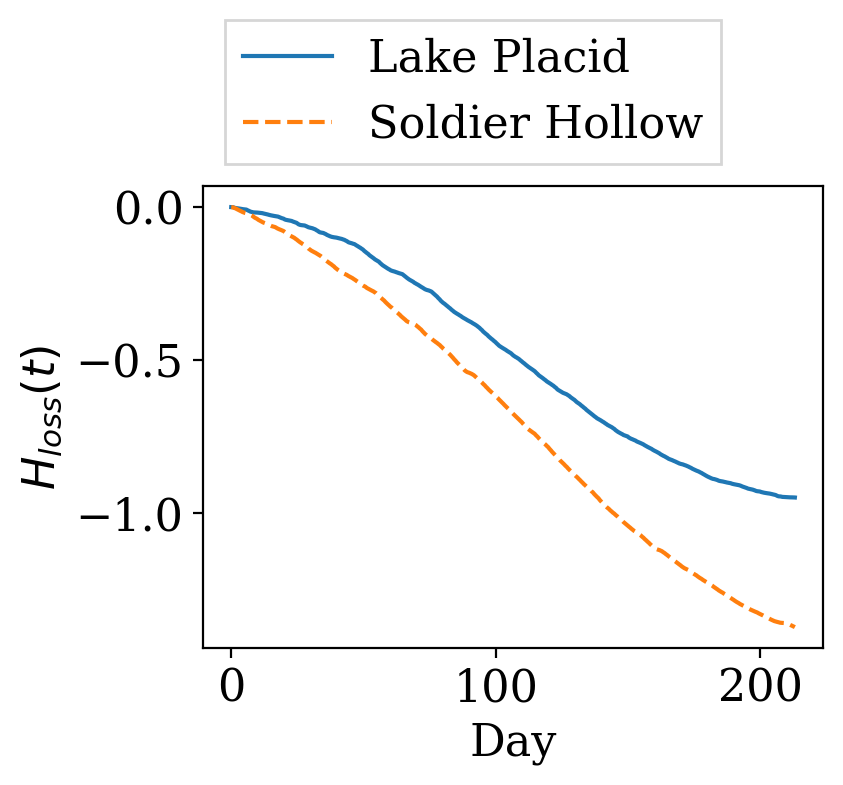

In [17]:
wallnumber = 4
loc = 'Lake Placid, NY'
fig, ax = plt.subplots(1,1,figsize=(4,3),dpi=200)
t = read_data(wallnumber,loc,'t')
H_t = read_data(wallnumber,loc,'H_t')
plt.plot(t/oneday,H_t[0] - H_t[:], label='Lake Placid')
loc = 'Soldier Hollow, UT'
t = read_data(wallnumber,loc,'t')
H_t = read_data(wallnumber,loc,'H_t')
plt.plot(t/oneday,H_t[0] - H_t[:],'--',label='Soldier Hollow')
plt.legend()
plt.xlabel('Day')
plt.ylabel("$H_{loss}(t)$")
plt.legend(loc='lower left', bbox_to_anchor=(0.0, 1.0),
          ncol=1, fancybox=False, shadow=False)
plt.show()

In [31]:
Numberofwalls = 5
losses_LP = np.zeros(Numberofwalls)
losses_SH = np.zeros(Numberofwalls)
loc = 'Lake Placid, NY'
for wallnumber in range(Numberofwalls):
    H_t = read_data(wallnumber,loc,'H_t')
    losses_LP[wallnumber] = (H_t[-1]-H_enc_ini)/((H_t[-1] - H_enc_ini) + H_final)*100
loc = 'Soldier Hollow, UT'
for wallnumber in range(Numberofwalls):
    H_t = read_data(wallnumber,loc,'H_t')
    losses_SH[wallnumber] = (H_t[-1]-H_enc_ini)/((H_t[-1] - H_enc_ini) + H_final)*100
losses_SH

array([66.52347655, 39.40619953, 25.11596563, 39.68553863, 21.54381422])

In [35]:

("wall "+str(i) for i in range(5))


<generator object <genexpr> at 0x16a20f4c0>

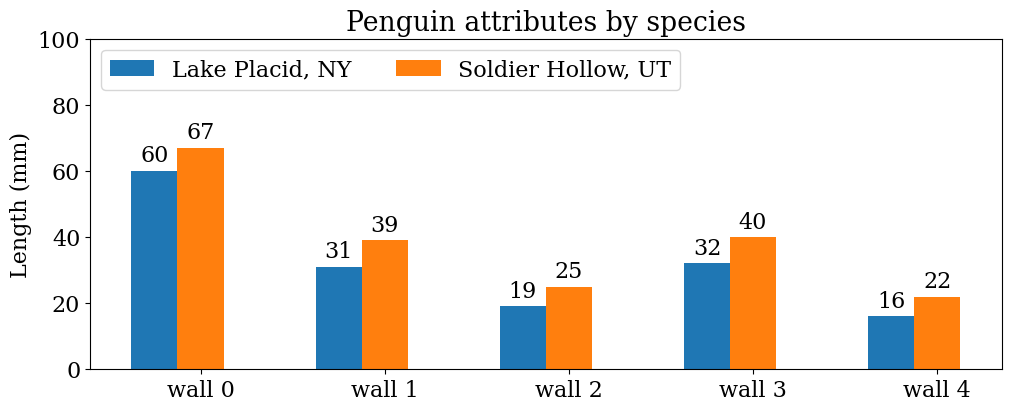

In [42]:
import matplotlib.pyplot as plt
import numpy as np

walls = []
for i in range(Numberofwalls):
    walls.append('wall %s' %i)

losses = {'Lake Placid, NY': losses_LP,
          'Soldier Hollow, UT': losses_SH}

x = np.arange(len(walls))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained',figsize=(10,4))

for attribute, loss in losses.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, np.round(loss), width, label=attribute)
    ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Length (mm)')
ax.set_title('Penguin attributes by species')
ax.set_xticks(x + width, walls)
ax.legend(loc='upper left', ncols=3)
ax.set_ylim(0, 100)

plt.show()



## Comparison solar irradiation heat flux on roof's inner surface.

In [ ]:
## Lake Placid

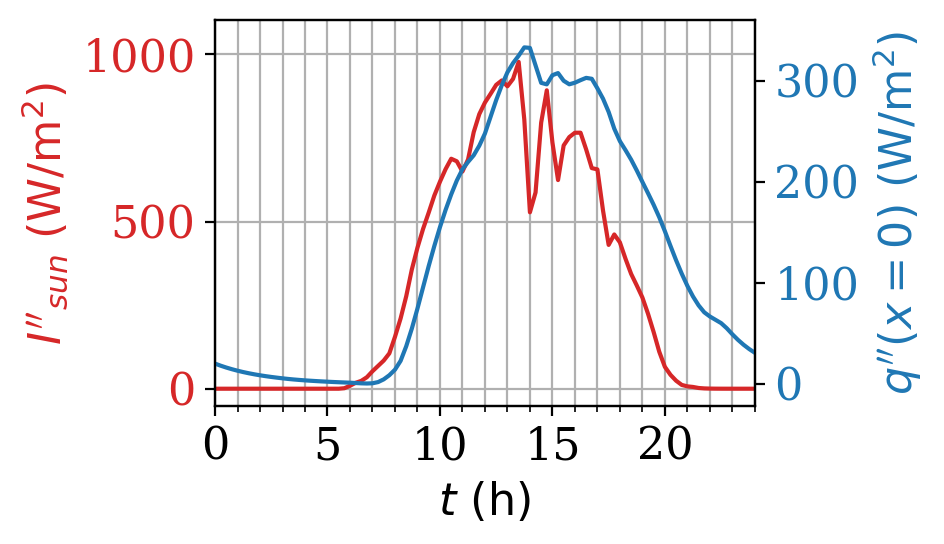

In [45]:
loc = 'Lake Placid, NY'
wallnumber = 0
locnospace = ''.join(loc.split())
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
t0 = 105*oneday
t1 = 1*oneday + t0
tmid = 0.5*(t0 + t1)
thalf = (t1 - t0)/2
fig, ax1 = plt.subplots(figsize=(5,3),dpi=200)


loc = 'Lake Placid, NY'
t = read_data(wallnumber, loc, 't')
qppx0and1 = read_data(wallnumber, loc, 'qppx0and1')
color = 'tab:red'
ax1.set_xlabel("$t~(\mathrm{h})$")
ax1.set_ylabel("$I''_{sun}~(\mathrm{W/m^2})$", color=color)
mask = np.where(np.abs(t - tmid) <= thalf)
ax1.plot((t - t0)/onehour,weatherfct[loc].sun_irradiation(t), color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xlim(0,(t1 - t0)/onehour)
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel(r"$q''(x=0)~(\mathrm{W/m^2})$", color=color)  # we already handled the x-label with ax1
ax2.plot((t - t0)/onehour,-qppx0and1[:,0], color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax1.xaxis.set_major_locator(MultipleLocator(5))
ax1.xaxis.set_major_formatter('{x:.0f}')

# For the minor ticks, use no labels; default NullFormatter.
ax1.xaxis.set_minor_locator(MultipleLocator(1))
ax1.grid(True, which='both')
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.savefig("fluxcomp%s.png"%locnospace,bbox_inches="tight")
plt.show()
f_LP.close()

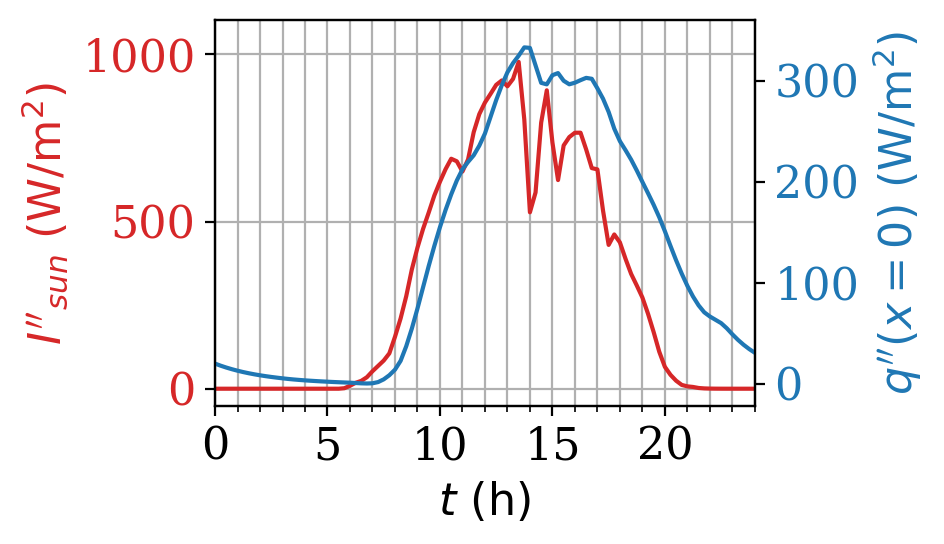

In [46]:
loc = 'Soldier Hollow, UT'
wallnumber = 0
locnospace = ''.join(loc.split())
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
t0 = 105*oneday
t1 = 1*oneday + t0
tmid = 0.5*(t0 + t1)
thalf = (t1 - t0)/2
fig, ax1 = plt.subplots(figsize=(5,3),dpi=200)


loc = 'Lake Placid, NY'
t = read_data(wallnumber, loc, 't')
qppx0and1 = read_data(wallnumber, loc, 'qppx0and1')
color = 'tab:red'
ax1.set_xlabel("$t~(\mathrm{h})$")
ax1.set_ylabel("$I''_{sun}~(\mathrm{W/m^2})$", color=color)
mask = np.where(np.abs(t - tmid) <= thalf)
ax1.plot((t - t0)/onehour,weatherfct[loc].sun_irradiation(t), color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xlim(0,(t1 - t0)/onehour)
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel(r"$q''(x=0)~(\mathrm{W/m^2})$", color=color)  # we already handled the x-label with ax1
ax2.plot((t - t0)/onehour,-qppx0and1[:,0], color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax1.xaxis.set_major_locator(MultipleLocator(5))
ax1.xaxis.set_major_formatter('{x:.0f}')

# For the minor ticks, use no labels; default NullFormatter.
ax1.xaxis.set_minor_locator(MultipleLocator(1))
ax1.grid(True, which='both')
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.savefig("fluxcomp%s.png"%locnospace,bbox_inches="tight")
plt.show()
f_LP.close()

In [48]:
weather[loc].keys()

Index(['Name', 'Wind Direction', 'Latitude', 'Cloud Cover',
       'Minimum Temperature', 'Precipitation', 'Solar Radiation', 'Dew Point',
       'Relative Humidity', 'ID', 'Precipitation Cover', 'Longitude', 'Info',
       'Temperature', 'Maximum Temperature', 'Visibility', 'Wind Speed',
       'Solar Energy', 'Heat Index', 'Weather Type', 'Snow Depth',
       'Sea Level Pressure', 'Snow', 'Name.1', 'Wind Gust', 'Conditions',
       'Wind Chill'],
      dtype='object')

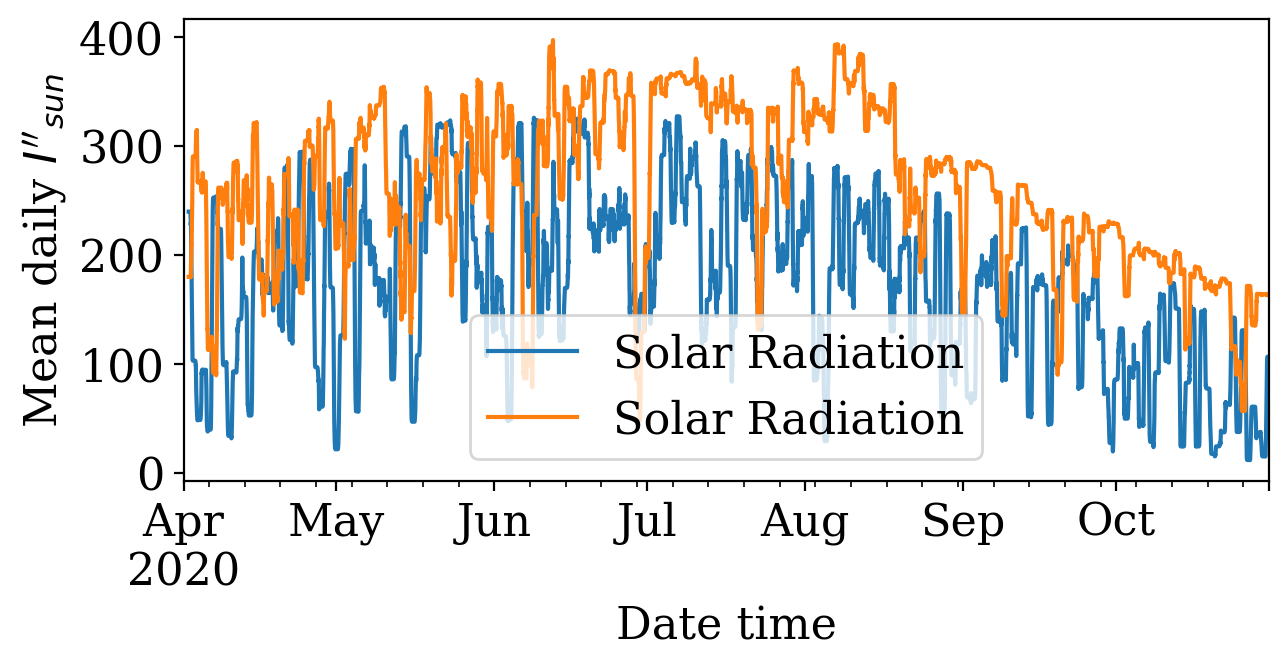

In [65]:
loc = 'Lake Placid, NY'
fig, ax0 = plt.subplots(1,1,figsize=(7,3),dpi=200)
weather[loc]['Solar Radiation'].rolling(window=96).mean().plot(ax = ax0)
loc = 'Soldier Hollow, UT'
weather[loc]['Solar Radiation'].rolling(window=96).mean().plot(ax = ax0)
plt.ylabel("Mean daily $I''_{sun}$")
plt.show()

In [59]:
weather[loc]

,Name,Wind Direction,Latitude,Cloud Cover,Minimum Temperature,Precipitation,Solar Radiation,Dew Point,Relative Humidity,ID,...,Solar Energy,Heat Index,Weather Type,Snow Depth,Sea Level Pressure,Snow,Name.1,Wind Gust,Conditions,Wind Chill
Date time,,,,,,,,,,,,,,,,,,,,,
2020-04-01 00:00:00,"Lake Placid, NY, United States",351.0,44.2821,0.0,-3.2,0.0,0.0,-8.1,69.11,e56bc4abbf,...,NaN,NaN,NaN,6.02,1013.9,0.0,"Lake Placid, NY, United States",NaN,Clear,NaN
2020-04-01 00:15:00,"Lake Placid, NY, United States",357.0,44.2821,0.0,-5.1,0.0,0.0,-7.9,80.39,e56bc4abbf,...,NaN,NaN,NaN,6.02,1013.3,0.0,"Lake Placid, NY, United States",NaN,Clear,NaN
2020-04-01 00:30:00,"Lake Placid, NY, United States",353.0,44.2821,0.0,-4.9,0.0,0.0,-7.9,79.72,e56bc4abbf,...,NaN,NaN,NaN,5.89,1013.3,0.0,"Lake Placid, NY, United States",NaN,Clear,NaN
2020-04-01 00:45:00,"Lake Placid, NY, United States",357.0,44.2821,0.0,-5.6,0.0,0.0,-7.7,84.69,e56bc4abbf,...,NaN,NaN,NaN,5.89,1014.6,0.0,"Lake Placid, NY, United States",NaN,Clear,NaN
2020-04-01 01:00:00,"Lake Placid, NY, United States",353.0,44.2821,0.0,-4.2,0.0,0.0,-7.7,76.86,e56bc4abbf,...,NaN,NaN,NaN,5.89,1013.3,0.0,"Lake Placid, NY, United States",NaN,Clear,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-10-30 23:00:00,"Lake Placid, NY, United States",351.0,44.2821,0.0,-7.9,0.0,0.0,-9.8,86.38,e56bc4abbf,...,NaN,NaN,NaN,0.00,1023.6,0.0,"Lake Placid, NY, United States",NaN,Clear,NaN
2020-10-30 23:15:00,"Lake Placid, NY, United States",0.0,44.2821,0.0,-8.0,0.0,0.0,-10.4,82.95,e56bc4abbf,...,NaN,NaN,NaN,0.00,1023.5,0.0,"Lake Placid, NY, United States",NaN,Clear,NaN
2020-10-30 23:30:00,"Lake Placid, NY, United States",10.0,44.2821,0.0,-9.2,0.0,0.0,-10.8,87.92,e56bc4abbf,...,NaN,NaN,NaN,0.00,1023.8,0.0,"Lake Placid, NY, United States",NaN,Clear,NaN


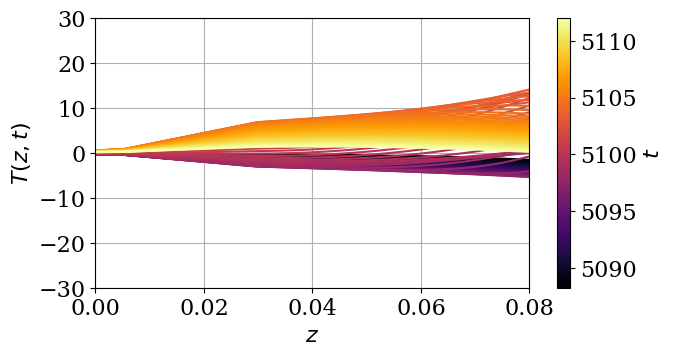

In [142]:
from matplotlib.collections import LineCollection
fig, axsm = plt.subplots(nrows=1,ncols=1,figsize=(7, 3.5))
undersampling = 12
# set axes limits manually because Collections do not take part in autoscaling
axsm.set_xlim(wall.grid.xs[0], wall.grid.xs[-1])
axsm.set_ylim(wall.dump.T[::,:,1].min(), wall.dump.T[:,:,1].max())
# ax.set_aspect("equal")  # to make the arcs look circular
mask = np.where(wall.dump.t > wall.dump.t[-1] - oneday)
# create a LineCollection with the half-circles and color mapping
line_collection = LineCollection(wall.dump.T[mask], array=wall.dump.t[mask]/onehour, cmap="inferno", linewidth=1.5)
axsm.add_collection(line_collection)
# axsm[0].set_xlim(-0.052,0.052)
axsm.set_xlabel(r"$z$")
axsm.set_ylabel(r"$T(z,t)$")
axsm.grid(True)
axsm.set_ylim(-30,30)
fig.colorbar(line_collection, label=r"$t$")
plt.savefig("example.pdf",bbox_inches='tight')
plt.show()